In [1]:
# import libs & define functions

import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import numpy as np
import imageio.v3 as iio
import os
import xml.etree.ElementTree as ET # Import for XML parsing
from math import ceil # For calculating canvas dimensions
from skimage.transform import resize # For potential tile resizing
import re # Import for regular expressions

# --- Function to parse stitching metadata ---
def parse_stitching_metadata(round_name, data_path):
    """
    Parses the Imaris stitching metadata from XML and TXT files for a given round.

    Args:
        round_name (str): The base name of the round (e.g., "Round0_30_300_1").
        data_path (str): The path to the directory containing the metadata files.

    Returns:
        dict: A dictionary containing:
            - 'tile_info': List of dicts, each with 'full_ims_path', 'min_x_um', 'min_y_um', 'max_x_um', 'max_y_um'.
            - 'tile_pixel_width': Width of a single tile in pixels.
            - 'tile_pixel_height': Height of a single tile in pixels.
            - 'effective_pixel_width_um': Effective physical width of one pixel in micrometers (derived).
            - 'effective_pixel_height_um': Effective physical height of one pixel in micrometers (derived).
            - 'overlap_pixels_x': Inferred overlap in pixels along X-axis.
            - 'overlap_pixels_y': Inferred overlap in pixels along Y-axis.
    """
    metadata = {
        'tile_info': [],
        'tile_pixel_width': None,
        'tile_pixel_height': None,
        'effective_pixel_width_um': None, # Derived from physical extent and pixel count
        'effective_pixel_height_um': None, # Derived from physical extent and pixel count
        'overlap_pixels_x': None,
        'overlap_pixels_y': None
    }

    # --- Parse _FusionStitcher_pair.xml for ImageExtends (physical coordinates) ---
    # This file provides the final, registered physical positions of the tiles.
    fusion_stitcher_pair_xml_filepath = os.path.join(data_path, f"{round_name}_FusionStitcher_pair.xml")
    print(f"Attempting to parse FusionStitcher_pair XML: {fusion_stitcher_pair_xml_filepath}")
    try:
        tree = ET.parse(fusion_stitcher_pair_xml_filepath)
        root = tree.getroot()
        for img_extend in root.findall(".//ImageExtends"):
            xml_image_path = img_extend.get("Image")
            base_filename = os.path.basename(xml_image_path)
            correct_full_ims_path = os.path.join(data_path, base_filename)

            min_coords_str = img_extend.get("ExtendMin").split()
            max_coords_str = img_extend.get("ExtendMax").split()

            min_x_um = float(min_coords_str[0])
            min_y_um = float(min_coords_str[1])
            max_x_um = float(max_coords_str[0])
            max_y_um = float(max_coords_str[1])

            metadata['tile_info'].append({
                'full_ims_path': correct_full_ims_path,
                'min_x_um': min_x_um,
                'min_y_um': min_y_um,
                'max_x_um': max_x_um,
                'max_y_um': max_y_um
            })
        print(f"FusionStitcher_pair XML parsing successful. Found {len(metadata['tile_info'])} tiles.")
    except FileNotFoundError:
        print(f"ERROR: FusionStitcher_pair XML file not found at {fusion_stitcher_pair_xml_filepath}")
        return None
    except Exception as e:
        print(f"ERROR parsing {fusion_stitcher_pair_xml_filepath}: {e}")
        return None

    # --- Parse _metadata.txt for pixel dimensions of individual tiles ---
    txt_filepath = os.path.join(data_path, f"{round_name}_metadata.txt")
    print(f"Attempting to parse TXT: {txt_filepath}")
    try:
        with open(txt_filepath, 'r') as f:
            for line in f:
                stripped_line = line.strip()

                if stripped_line.startswith("Width="):
                    metadata['tile_pixel_width'] = int(stripped_line.split('=')[1].strip())
                    print(f"Found tile_pixel_width: {metadata['tile_pixel_width']}")
                elif stripped_line.startswith("Height="):
                    metadata['tile_pixel_height'] = int(stripped_line.split('=')[1].strip())
                    print(f"Found tile_pixel_height: {metadata['tile_pixel_height']}")
        print("TXT parsing complete.")
    except FileNotFoundError:
        print(f"ERROR: TXT file not found at {txt_filepath}")
        return None
    except Exception as e:
        print(f"ERROR parsing {txt_filepath}: {e}")
        return None

    # --- Parse TeraStitcher XML for precise voxel dimensions and pixel overlap ---
    # This is the Round1_CD8_A19_30_300.xml file
    terastitcher_xml_filepath = os.path.join(data_path, f"{round_name}.xml")
    print(f"Attempting to parse TeraStitcher XML: {terastitcher_xml_filepath}")
    try:
        tree = ET.parse(terastitcher_xml_filepath)
        root = tree.getroot()
        
        # Get voxel dimensions (effective pixel size)
        voxel_dims_elem = root.find(".//voxel_dims")
        if voxel_dims_elem is not None:
            voxel_h = float(voxel_dims_elem.get("H")) # X-axis pixel size
            voxel_v = float(voxel_dims_elem.get("V")) # Y-axis pixel size (might be negative)
            metadata['effective_pixel_width_um'] = abs(voxel_h)
            metadata['effective_pixel_height_um'] = abs(voxel_v)
            print(f"Derived effective_pixel_width_um from TeraStitcher XML: {metadata['effective_pixel_width_um']:.4f}")
            print(f"Derived effective_pixel_height_um from TeraStitcher XML: {metadata['effective_pixel_height_um']:.4f}")
        else:
            print("WARNING: Could not find <voxel_dims> in TeraStitcher XML. Will derive from FusionStitcher_pair.xml as fallback.")

        # Try to infer overlap from ABS_H/ABS_V if available
        # We need at least two stacks in the same row/column to calculate offset
        first_stack = root.find(".//STACKS/Stack[@COL='0'][@ROW='0']")
        second_stack_h = root.find(".//STACKS/Stack[@COL='1'][@ROW='0']")
        second_stack_v = root.find(".//STACKS/Stack[@COL='0'][@ROW='1']")

        if first_stack and second_stack_h and metadata['tile_pixel_width']:
            abs_h_first = int(first_stack.get("ABS_H"))
            abs_h_second = int(second_stack_h.get("ABS_H"))
            pixel_offset_x = abs_h_second - abs_h_first
            metadata['overlap_pixels_x'] = metadata['tile_pixel_width'] - pixel_offset_x
            print(f"Inferred overlap_pixels_x from TeraStitcher XML: {metadata['overlap_pixels_x']} pixels")

        if first_stack and second_stack_v and metadata['tile_pixel_height']:
            abs_v_first = int(first_stack.get("ABS_V"))
            abs_v_second = int(second_stack_v.get("ABS_V"))
            pixel_offset_y = abs_v_second - abs_v_first
            metadata['overlap_pixels_y'] = metadata['tile_pixel_height'] - pixel_offset_y
            print(f"Inferred overlap_pixels_y from TeraStitcher XML: {metadata['overlap_pixels_y']} pixels")

    except FileNotFoundError:
        print(f"WARNING: TeraStitcher XML file not found at {terastitcher_xml_filepath}. Cannot infer pixel overlap from it.")
    except Exception as e:
        print(f"ERROR parsing {terastitcher_xml_filepath}: {e}")

    # --- Fallback for effective pixel size if not found in TeraStitcher XML ---
    if metadata['effective_pixel_width_um'] is None and metadata['tile_info'] and metadata['tile_pixel_width'] and metadata['tile_pixel_height']:
        first_tile = metadata['tile_info'][0]
        physical_width_first_tile = first_tile['max_x_um'] - first_tile['min_x_um']
        physical_height_first_tile = first_tile['max_y_um'] - first_tile['min_y_um']

        metadata['effective_pixel_width_um'] = physical_width_first_tile / metadata['tile_pixel_width']
        metadata['effective_pixel_height_um'] = physical_height_first_tile / metadata['tile_pixel_height']
        print(f"Derived effective_pixel_width_um from FusionStitcher_pair.xml (fallback): {metadata['effective_pixel_width_um']:.4f}")
        print(f"Derived effective_pixel_height_um from FusionStitcher_pair.xml (fallback): {metadata['effective_pixel_height_um']:.4f}")
    elif metadata['effective_pixel_width_um'] is None:
        print("ERROR: Cannot derive effective pixel size. Missing tile info or pixel dimensions.")
        return None

    # --- Fallback for overlap pixels if not found in TeraStitcher XML ---
    # These are only strictly needed for 'feather' method, but good to have for consistency
    if metadata['overlap_pixels_x'] is None:
        print("WARNING: Could not infer X overlap pixels from TeraStitcher XML. Using a default of 20 pixels.")
        metadata['overlap_pixels_x'] = 20
    if metadata['overlap_pixels_y'] is None:
        print("WARNING: Could not infer Y overlap pixels from TeraStitcher XML. Using a default of 20 pixels.")
        metadata['overlap_pixels_y'] = 20


    # Basic validation
    if not all([metadata['tile_info'], metadata['tile_pixel_width'],
                metadata['tile_pixel_height'], metadata['effective_pixel_width_um'],
                metadata['effective_pixel_height_um'], metadata['overlap_pixels_x'] is not None,
                metadata['overlap_pixels_y'] is not None]):
        print("ERROR: Missing critical metadata after parsing. One or more values are None.")
        return None

    return metadata


# --- Function to stitch Max Z Projections with configurable overlap handling ---
def stitch_max_z_projection(stitching_metadata, output_filename, round_name,
                            current_round_num, total_rounds, overlap_method, # Added overlap_method
                            channel_index=0, time_index=0, scene_index=0):
    """
    Calculates Max Z Projection for each tile and stitches them into a single image
    using a configurable overlap handling method ('max_int', 'avg_int', 'feather').

    Args:
        stitching_metadata (dict): Dictionary containing parsed metadata from parse_stitching_metadata.
        output_filename (str): Full path to save the stitched TIFF image.
        round_name (str): The base name of the round (e.g., "Round0_30_300_1"). Used for plot title.
        current_round_num (int): The 1-based index of the current round being processed.
        total_rounds (int): The total number of rounds to be processed.
        overlap_method (str): Method to handle overlap regions: 'max_int', 'avg_int', or 'feather'.
        channel_index (int): The channel index to use for Max Z Projection (default is 0).
        time_index (int): The time point index to use (default is 0).
        scene_index (int): The scene index to use (default is 0).

    Returns:
        np.ndarray: The stitched image array, or None if an error occurred.
    """
    if not stitching_metadata:
        print("Error: No stitching metadata provided.")
        return None

    tile_info = stitching_metadata['tile_info']
    tile_pixel_width = stitching_metadata['tile_pixel_width']
    tile_pixel_height = stitching_metadata['tile_pixel_height']
    pixel_width_um = stitching_metadata['effective_pixel_width_um']
    pixel_height_um = stitching_metadata['effective_pixel_height_um']
    overlap_pixels_x = stitching_metadata['overlap_pixels_x']
    overlap_pixels_y = stitching_metadata['overlap_pixels_y']

    # 1. Determine overall physical bounds of the stitched image
    min_x_um_global = float('inf')
    min_y_um_global = float('inf')
    max_x_um_global = float('-inf')
    max_y_um_global = float('-inf')

    for tile in tile_info:
        min_x_um_global = min(min_x_um_global, tile['min_x_um'])
        min_y_um_global = min(min_y_um_global, tile['min_y_um'])
        max_x_um_global = max(max_x_um_global, tile['max_x_um'])
        max_y_um_global = max(max_y_um_global, tile['max_y_um'])

    print(f"\nGlobal physical bounds (µm):")
    print(f"  X: [{min_x_um_global:.2f}, {max_x_um_global:.2f}]")
    print(f"  Y: [{min_y_um_global:.2f}, {max_y_um_global:.2f}]")

    # 2. Calculate overall pixel dimensions for the canvas
    overall_width_um = max_x_um_global - min_x_um_global
    overall_height_um = max_y_um_global - min_y_um_global

    canvas_width_pixels = int(ceil(overall_width_um / pixel_width_um))
    canvas_height_pixels = int(ceil(overall_height_um / pixel_height_um))

    print(f"Calculated canvas dimensions: {canvas_width_pixels}x{canvas_height_pixels} pixels")

    # Initialize canvases based on overlap_method
    if overlap_method == 'max_int':
        stitched_image_canvas = np.zeros((canvas_height_pixels, canvas_width_pixels), dtype=np.uint16)
        print(f"Initialized stitched image canvas for 'max_int' of shape {stitched_image_canvas.shape} with dtype {stitched_image_canvas.dtype}")
    elif overlap_method == 'avg_int':
        stitched_image_sum = np.zeros((canvas_height_pixels, canvas_width_pixels), dtype=np.float32)
        stitched_image_count = np.zeros((canvas_height_pixels, canvas_width_pixels), dtype=np.uint8)
        print(f"Initialized sum canvas for 'avg_int' of shape {stitched_image_sum.shape} with dtype {stitched_image_sum.dtype}")
        print(f"Initialized count canvas for 'avg_int' of shape {stitched_image_count.shape} with dtype {stitched_image_count.dtype}")
    elif overlap_method == 'feather':
        weighted_sum_canvas = np.zeros((canvas_height_pixels, canvas_width_pixels), dtype=np.float32)
        total_weight_canvas = np.zeros((canvas_height_pixels, canvas_width_pixels), dtype=np.float32)
        print(f"Initialized weighted sum canvas for 'feather' of shape {weighted_sum_canvas.shape} with dtype {weighted_sum_canvas.dtype}")
        print(f"Initialized total weight canvas for 'feather' of shape {total_weight_canvas.shape} with dtype {total_weight_canvas.dtype}")
    else:
        print(f"ERROR: Unknown overlap_method '{overlap_method}'. Supported: 'max_int', 'avg_int', 'feather'.")
        return None

    # 3. Process and stitch each tile
    total_tiles = len(tile_info)
    for i, tile in enumerate(tile_info):
        print(f"Processing Round {current_round_num} of {total_rounds}; tile {i+1}/{total_tiles}: {os.path.basename(tile['full_ims_path'])}")
        try:
            img = AICSImage(tile['full_ims_path'])
            image_data_zyx = img.get_image_data("ZYX", T=time_index, S=scene_index, C=channel_index)

            if image_data_zyx.shape[0] > 1:
                projected_tile = np.max(image_data_zyx, axis=0)
            else:
                projected_tile = image_data_zyx[0, :, :]

            # Convert tile physical coordinates to canvas pixel coordinates
            tile_offset_x_um = tile['min_x_um'] - min_x_um_global
            tile_offset_y_um = tile['min_y_um'] - min_y_um_global

            tile_start_x_px = int(round(tile_offset_x_um / pixel_width_um))
            tile_start_y_px = int(round(tile_offset_y_um / pixel_height_um))

            # Calculate end pixel coordinates for the tile on the canvas
            tile_end_x_px_ideal = tile_start_x_px + tile_pixel_width
            tile_end_y_px_ideal = tile_start_y_px + tile_pixel_height

            # Ensure the projected tile matches the expected dimensions from metadata
            if projected_tile.shape[0] != tile_pixel_height or projected_tile.shape[1] != tile_pixel_width:
                print(f"Warning: Tile {os.path.basename(tile['full_ims_path'])} has dimensions {projected_tile.shape} but metadata expects {tile_pixel_height}x{tile_pixel_width}. Resizing...")
                # Resize and cast to float32 for avg/feather, or uint16 for max_int
                if overlap_method in ['avg_int', 'feather']:
                    projected_tile = resize(projected_tile, (tile_pixel_height, tile_pixel_width), anti_aliasing=True, preserve_range=True).astype(np.float32)
                else: # max_int
                    projected_tile = resize(projected_tile, (tile_pixel_height, tile_pixel_width), anti_aliasing=True, preserve_range=True).astype(np.uint16)
            else:
                if overlap_method in ['avg_int', 'feather']:
                    projected_tile = projected_tile.astype(np.float32) # Ensure float32 for calculations

            # Determine the actual slice on the canvas, considering canvas boundaries
            canvas_slice_y_start = tile_start_y_px
            canvas_slice_y_end = min(tile_end_y_px_ideal, canvas_height_pixels)
            canvas_slice_x_start = tile_start_x_px
            canvas_slice_x_end = min(tile_end_x_px_ideal, canvas_width_pixels)

            current_tile_height = canvas_slice_y_end - canvas_slice_y_start
            current_tile_width = canvas_slice_x_end - canvas_slice_x_start

            if current_tile_height <= 0 or current_tile_width <= 0:
                print(f"Warning: Tile {os.path.basename(tile['full_ims_path'])} results in zero or negative dimensions after canvas boundary check. Skipping.")
                continue

            projected_tile_cropped = projected_tile[:current_tile_height, :current_tile_width]

            # --- Apply overlap method ---
            if overlap_method == 'max_int':
                target_slice = stitched_image_canvas[canvas_slice_y_start:canvas_slice_y_end, canvas_slice_x_start:canvas_slice_x_end]
                if target_slice.shape == projected_tile_cropped.shape:
                    stitched_image_canvas[canvas_slice_y_start:canvas_slice_y_end, canvas_slice_x_start:canvas_slice_x_end] = \
                        np.maximum(target_slice, projected_tile_cropped)
                else:
                    print(f"ERROR: Mismatch in dimensions for max_int when placing tile {os.path.basename(tile['full_ims_path'])}. Target slice shape: {target_slice.shape}, Projected tile shape: {projected_tile_cropped.shape}")

            elif overlap_method == 'avg_int':
                stitched_image_sum[canvas_slice_y_start:canvas_slice_y_end, canvas_slice_x_start:canvas_slice_x_end] += projected_tile_cropped
                stitched_image_count[canvas_slice_y_start:canvas_slice_y_end, canvas_slice_x_start:canvas_slice_x_end] += 1

            elif overlap_method == 'feather':
                tile_weight_map = np.ones_like(projected_tile, dtype=np.float32)

                # Apply linear gradients for X overlaps
                if overlap_pixels_x > 0:
                    # Left overlap region
                    if tile_start_x_px > 0:
                        ramp_left = np.linspace(0.0, 1.0, overlap_pixels_x)
                        tile_weight_map[:, :overlap_pixels_x] *= ramp_left
                    # Right overlap region
                    if tile_end_x_px_ideal < canvas_width_pixels:
                        ramp_right = np.linspace(1.0, 0.0, overlap_pixels_x)
                        tile_weight_map[:, (tile_pixel_width - overlap_pixels_x):] *= ramp_right

                # Apply linear gradients for Y overlaps
                if overlap_pixels_y > 0:
                    # Top overlap region
                    if tile_start_y_px > 0:
                        ramp_top = np.linspace(0.0, 1.0, overlap_pixels_y)
                        tile_weight_map[:overlap_pixels_y, :] *= ramp_top.reshape(-1, 1)
                    # Bottom overlap region
                    if tile_end_y_px_ideal < canvas_height_pixels:
                        ramp_bottom = np.linspace(1.0, 0.0, overlap_pixels_y)
                        tile_weight_map[(tile_pixel_height - overlap_pixels_y):, :] *= ramp_bottom.reshape(-1, 1)

                tile_weight_map_cropped = tile_weight_map[:current_tile_height, :current_tile_width]

                weighted_sum_canvas[canvas_slice_y_start:canvas_slice_y_end, canvas_slice_x_start:canvas_slice_x_end] += \
                    projected_tile_cropped * tile_weight_map_cropped
                total_weight_canvas[canvas_slice_y_start:canvas_slice_y_end, canvas_slice_x_start:canvas_slice_x_end] += \
                    tile_weight_map_cropped

        except Exception as e:
            print(f"Error processing tile {os.path.basename(tile['full_ims_path'])}: {e}")
            continue

    # 4. Finalize the stitched image based on overlap_method
    stitched_image = None
    if overlap_method == 'max_int':
        stitched_image = stitched_image_canvas
    elif overlap_method == 'avg_int':
        stitched_image = np.divide(stitched_image_sum, stitched_image_count,
                                    out=np.zeros_like(stitched_image_sum),
                                    where=stitched_image_count != 0)
        stitched_image = np.clip(stitched_image, 0, 65535).astype(np.uint16)
    elif overlap_method == 'feather':
        stitched_image = np.divide(weighted_sum_canvas, total_weight_canvas,
                                    out=np.zeros_like(weighted_sum_canvas),
                                    where=total_weight_canvas != 0)
        stitched_image = np.clip(stitched_image, 0, 65535).astype(np.uint16)

    if stitched_image is None:
        print("ERROR: Stitched image could not be finalized.")
        return None

    # 5. Save stitched image
    try:
        iio.imwrite(output_filename, stitched_image)
        print(f"\nSuccessfully saved stitched image to '{output_filename}'")
    except Exception as e:
        print(f"Error saving stitched image to '{output_filename}': {e}")
        return None

    # 6. Display (optional)
    plt.figure(figsize=(12, 12))
    plt.imshow(stitched_image, cmap='gray')
    plt.title(f"Stitched {overlap_method.replace('_', ' ').title()} Z Projection for {round_name}")
    plt.colorbar(label='Intensity')
    plt.axis('off')
    plt.show()

    return stitched_image

print("All functions go!")

All functions go!


In [2]:
# --- GLOBAL CONFIGURATION ---
# Define the desired overlap handling method:
# Options: 'max_int', 'avg_int', 'feather'
OVERLAP_METHOD = 'feather' # <--- SET YOUR DESIRED OVERLAP METHOD HERE ---

# user inputs
data_path = r"E:\20250404_DNA_PAINT_12 targets_ON testing"

Ensured output directory exists: E:\20250404_DNA_PAINT_12 targets_ON testing\analysis_results_Feather_AtOverlap
Found 15 unique rounds to process: Round0_30_300, Round0_30_300_1, Round10_CD45_A27_30_300, Round11_SMA_A25_30_300, Round12_panCK_A38_30_300, Round13_CD3_A8_30_300, Round1_CD8_A19_30_300, Round2_CD3_A8_30_300, Round3_CD4_A39_30_300, Round4_CD20_A3_30_300, Round5_Tom20_A20_30_300, Round6_CD63_A10_30_300, Round7_CD19_A36_30_300, Round8_Vimentin_A5_30_300, Round9_Ki67_A15_30_300

--- Processing Round 1 of 15: Round0_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300.

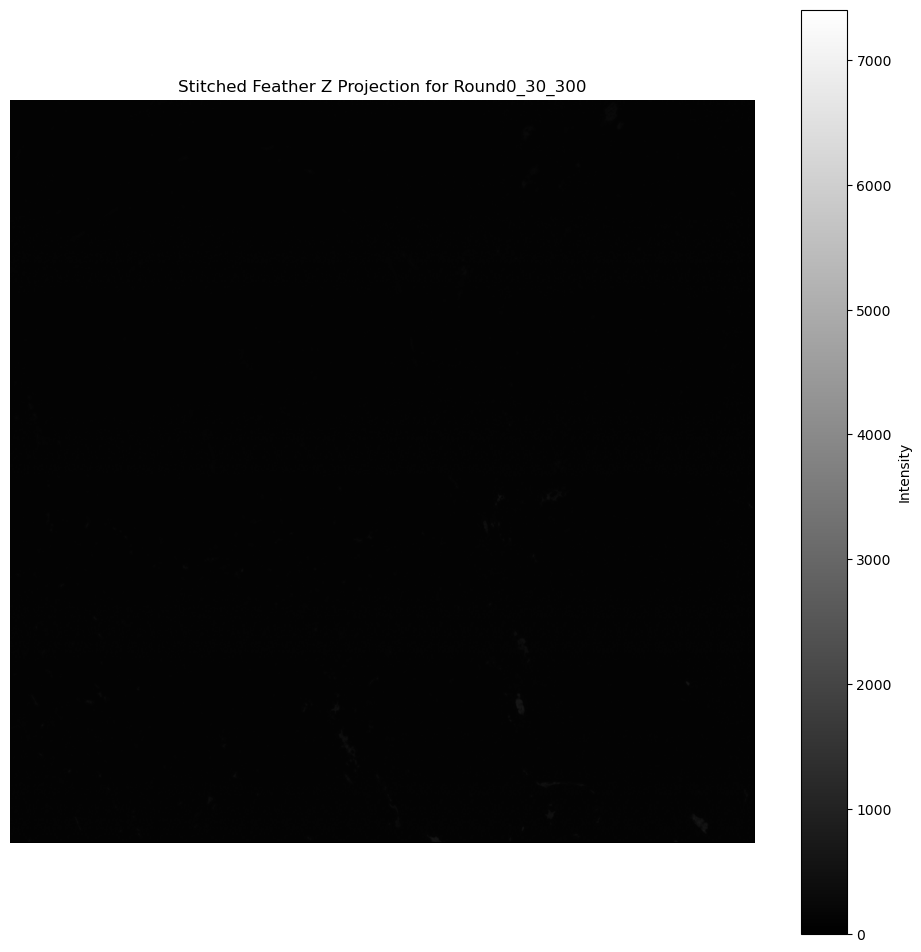

Stitching process completed for Round0_30_300.
--- Finished Round 1 of 15: Round0_30_300 ---


--- Processing Round 2 of 15: Round0_30_300_1 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_1_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_1_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_1.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1500x0.1500 µm
Inferred over

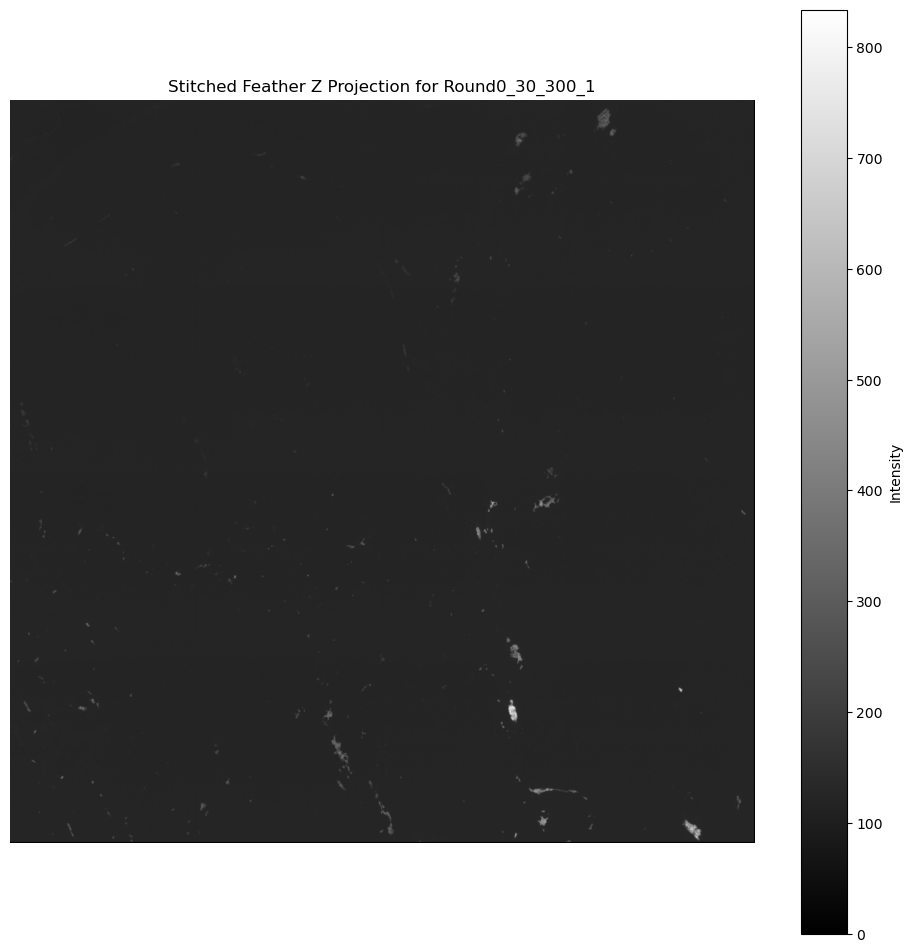

Stitching process completed for Round0_30_300_1.
--- Finished Round 2 of 15: Round0_30_300_1 ---


--- Processing Round 3 of 15: Round10_CD45_A27_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round10_CD45_A27_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round10_CD45_A27_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round10_CD45_A27_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel 

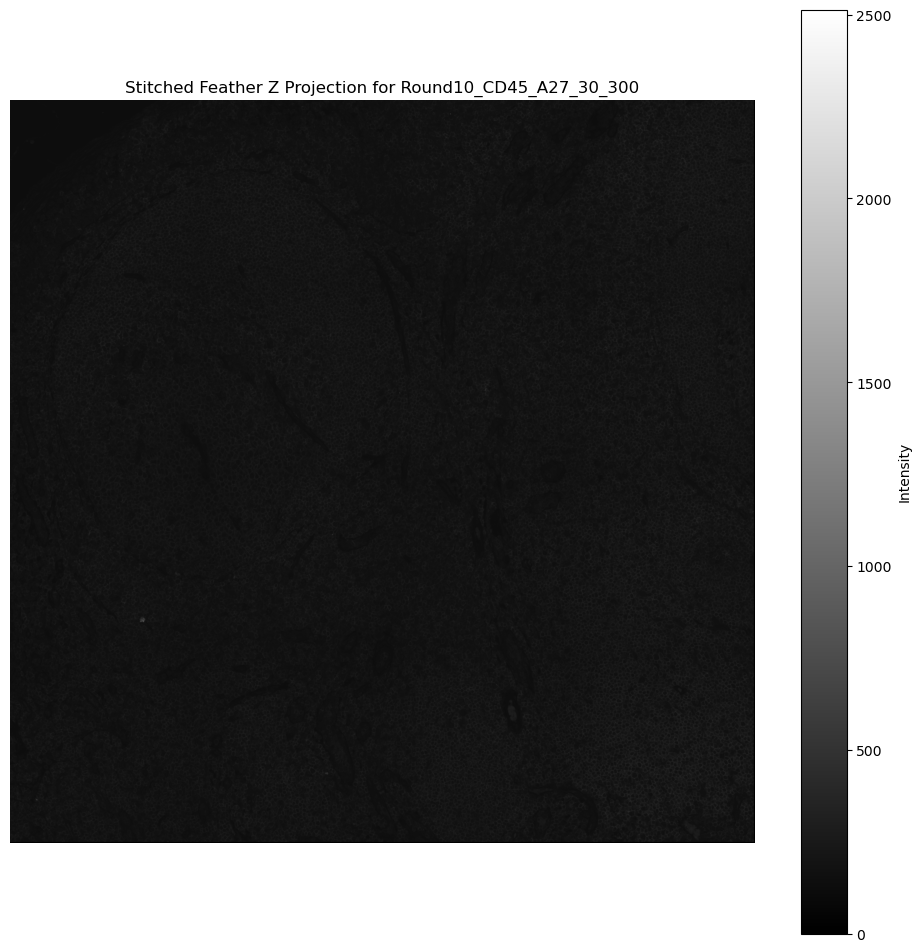

Stitching process completed for Round10_CD45_A27_30_300.
--- Finished Round 3 of 15: Round10_CD45_A27_30_300 ---


--- Processing Round 4 of 15: Round11_SMA_A25_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round11_SMA_A25_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round11_SMA_A25_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round11_SMA_A25_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective phy

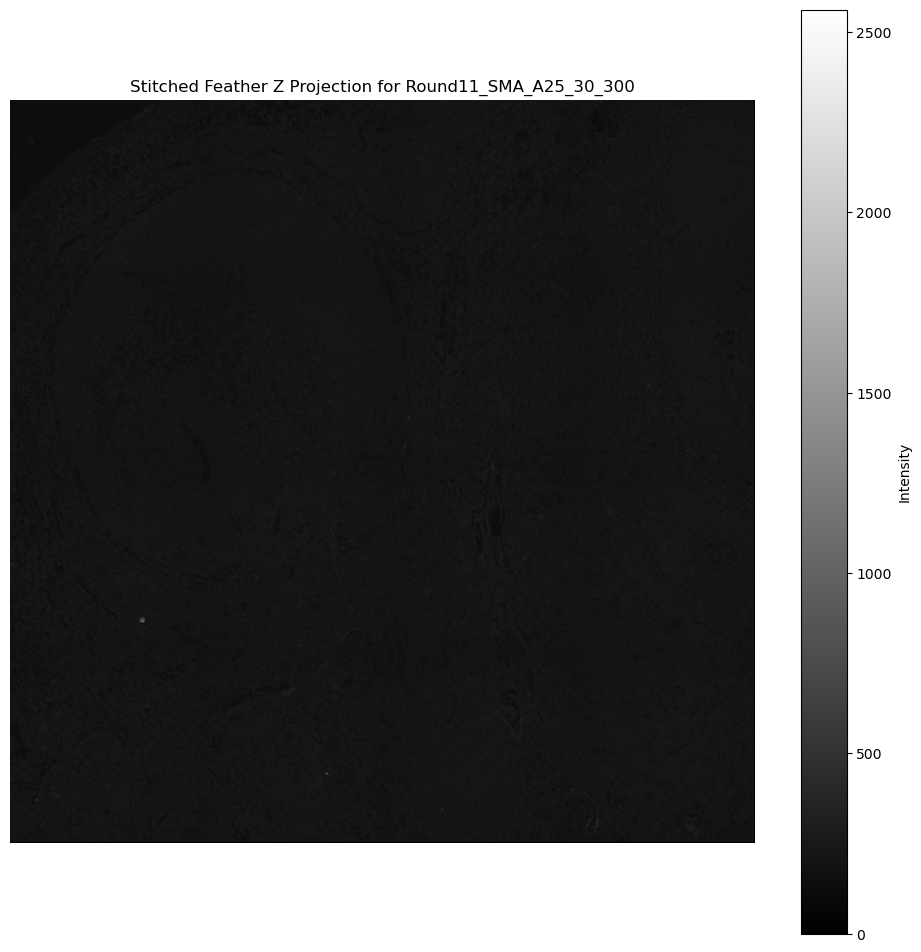

Stitching process completed for Round11_SMA_A25_30_300.
--- Finished Round 4 of 15: Round11_SMA_A25_30_300 ---


--- Processing Round 5 of 15: Round12_panCK_A38_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round12_panCK_A38_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round12_panCK_A38_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round12_panCK_A38_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effecti

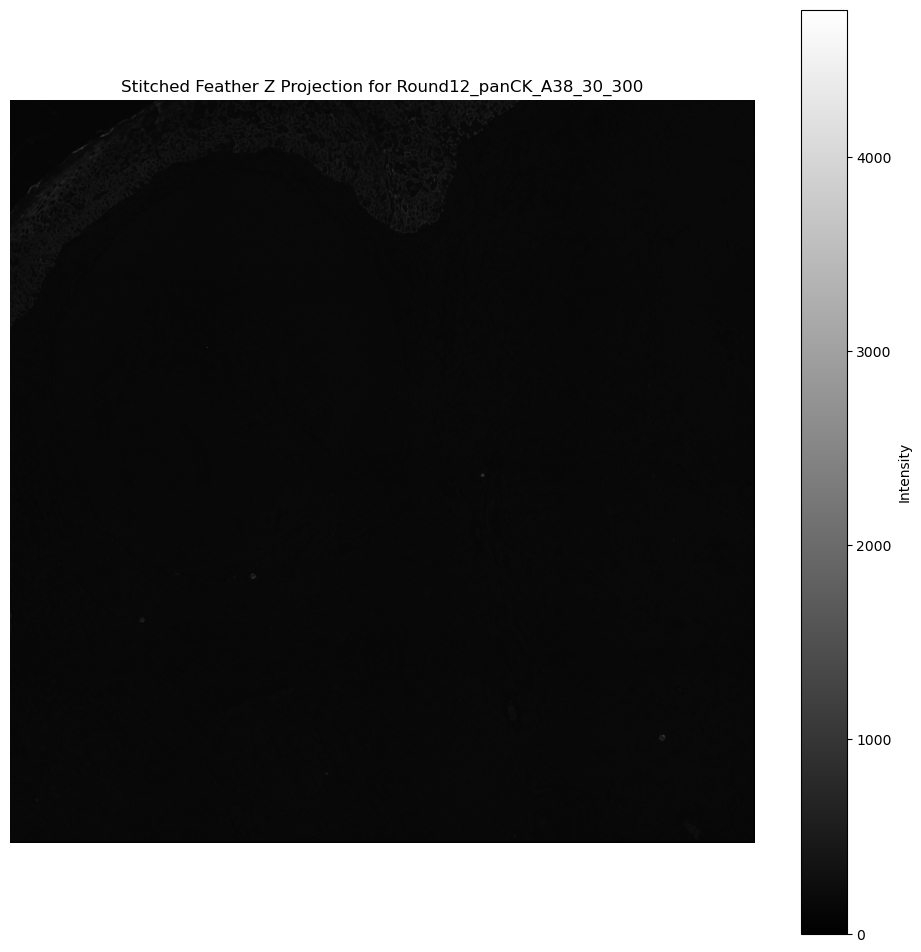

Stitching process completed for Round12_panCK_A38_30_300.
--- Finished Round 5 of 15: Round12_panCK_A38_30_300 ---


--- Processing Round 6 of 15: Round13_CD3_A8_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round13_CD3_A8_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round13_CD3_A8_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round13_CD3_A8_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physi

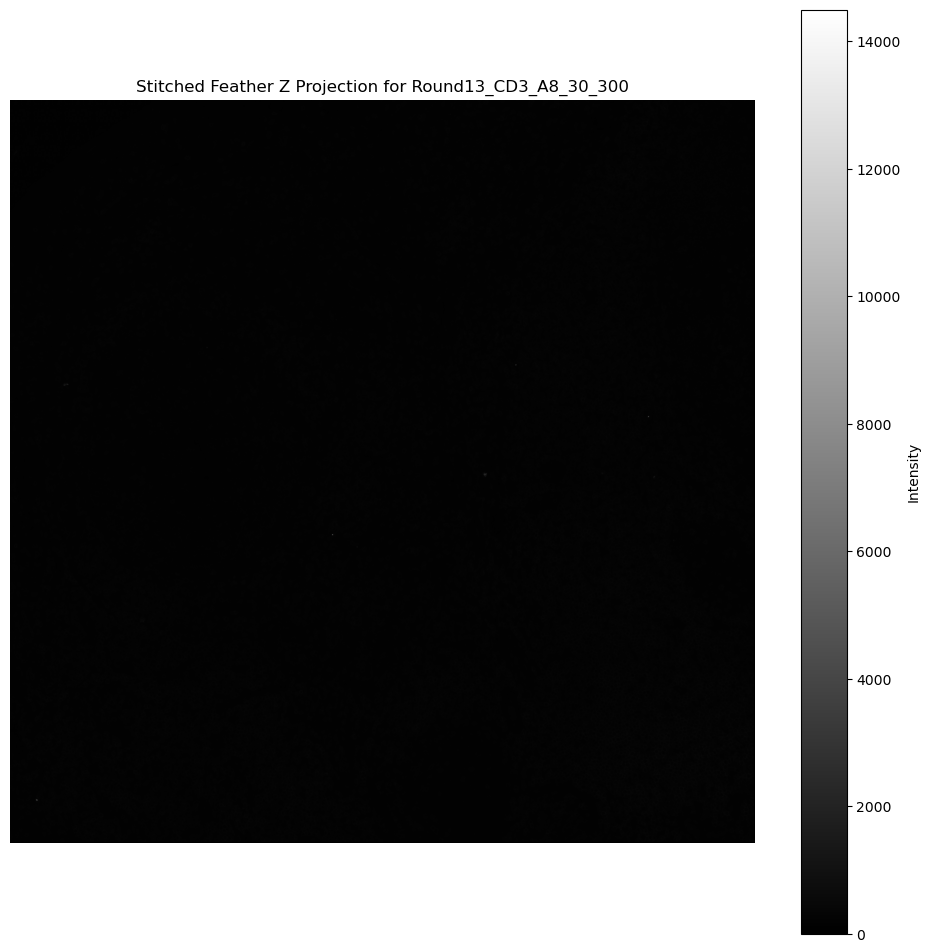

Stitching process completed for Round13_CD3_A8_30_300.
--- Finished Round 6 of 15: Round13_CD3_A8_30_300 ---


--- Processing Round 7 of 15: Round1_CD8_A19_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round1_CD8_A19_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round1_CD8_A19_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round1_CD8_A19_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pi

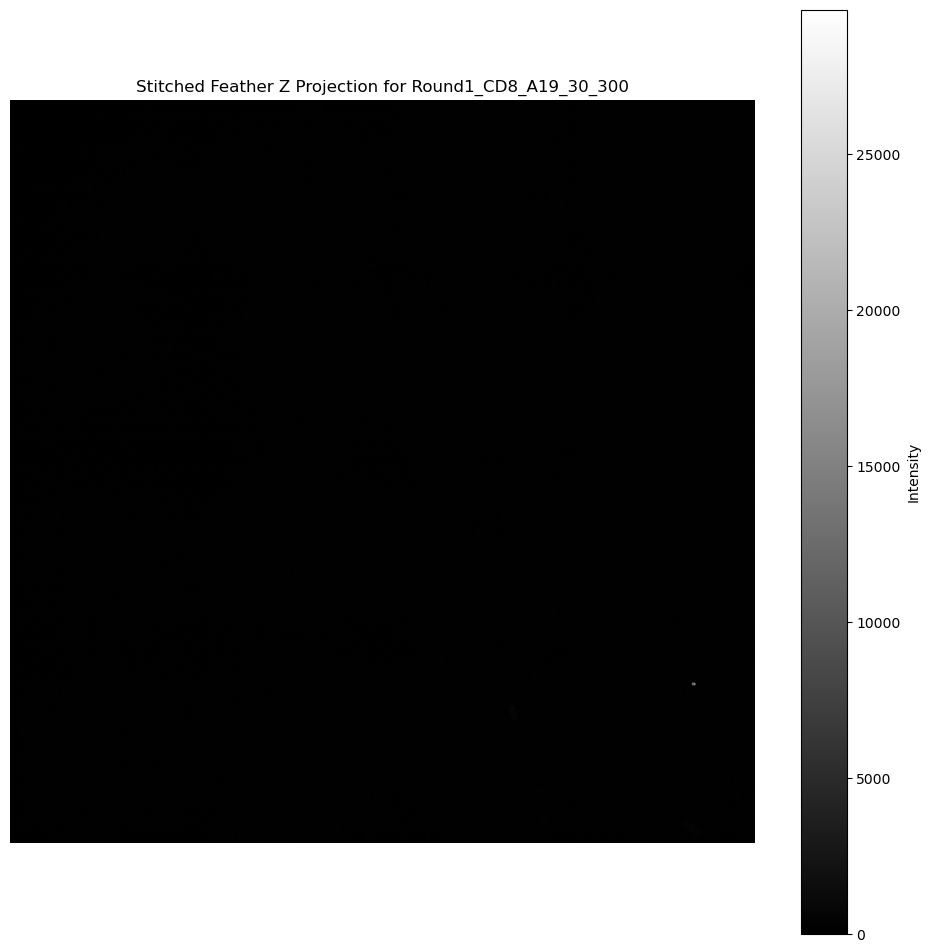

Stitching process completed for Round1_CD8_A19_30_300.
--- Finished Round 7 of 15: Round1_CD8_A19_30_300 ---


--- Processing Round 8 of 15: Round2_CD3_A8_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round2_CD3_A8_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round2_CD3_A8_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round2_CD3_A8_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel 

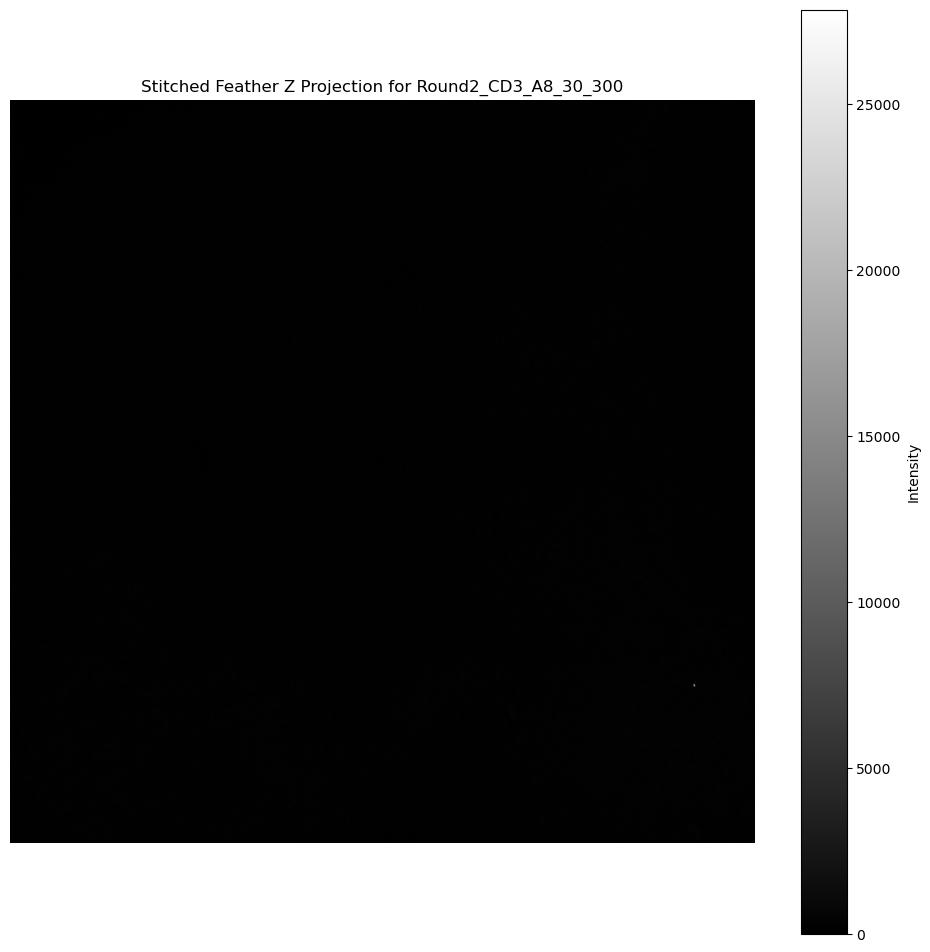

Stitching process completed for Round2_CD3_A8_30_300.
--- Finished Round 8 of 15: Round2_CD3_A8_30_300 ---


--- Processing Round 9 of 15: Round3_CD4_A39_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round3_CD4_A39_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round3_CD4_A39_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round3_CD4_A39_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixe

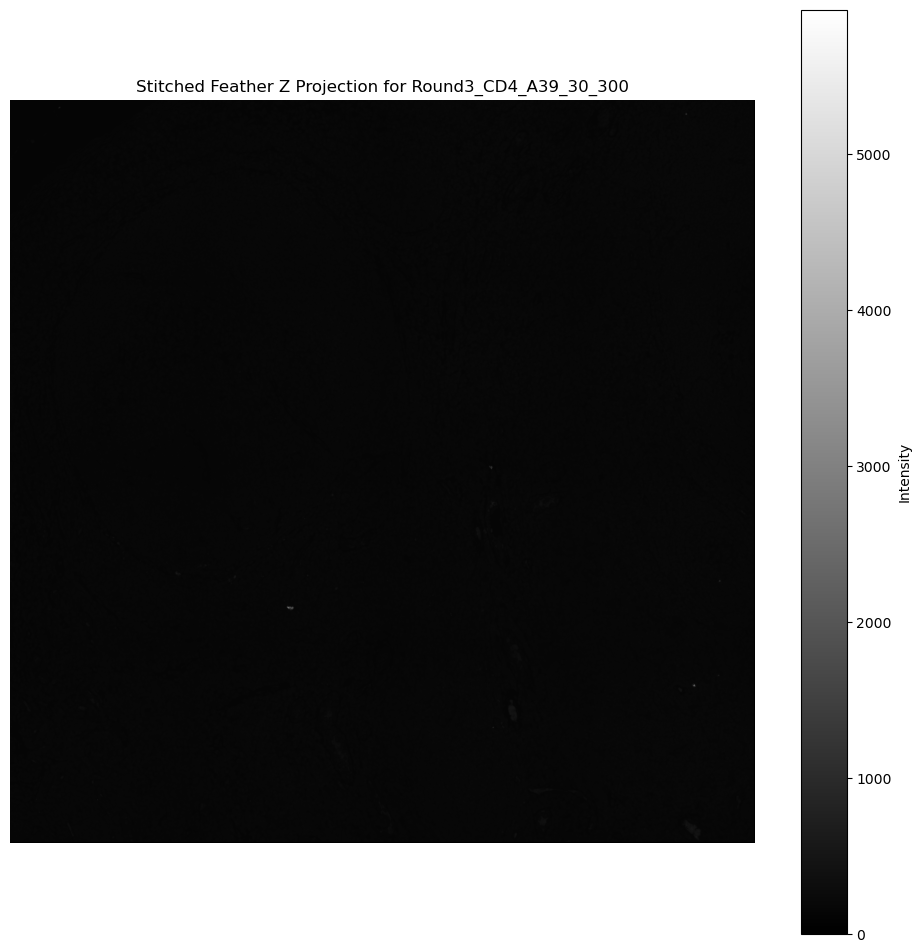

Stitching process completed for Round3_CD4_A39_30_300.
--- Finished Round 9 of 15: Round3_CD4_A39_30_300 ---


--- Processing Round 10 of 15: Round4_CD20_A3_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round4_CD20_A3_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round4_CD20_A3_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round4_CD20_A3_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical p

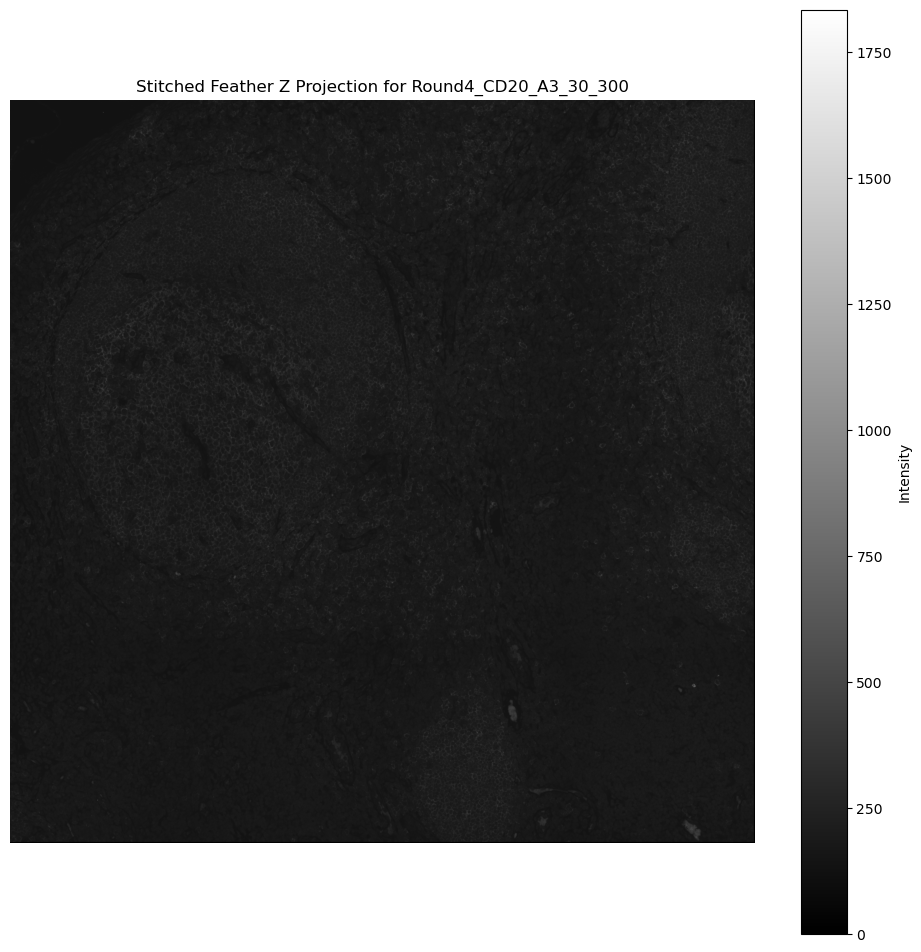

Stitching process completed for Round4_CD20_A3_30_300.
--- Finished Round 10 of 15: Round4_CD20_A3_30_300 ---


--- Processing Round 11 of 15: Round5_Tom20_A20_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round5_Tom20_A20_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round5_Tom20_A20_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round5_Tom20_A20_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective p

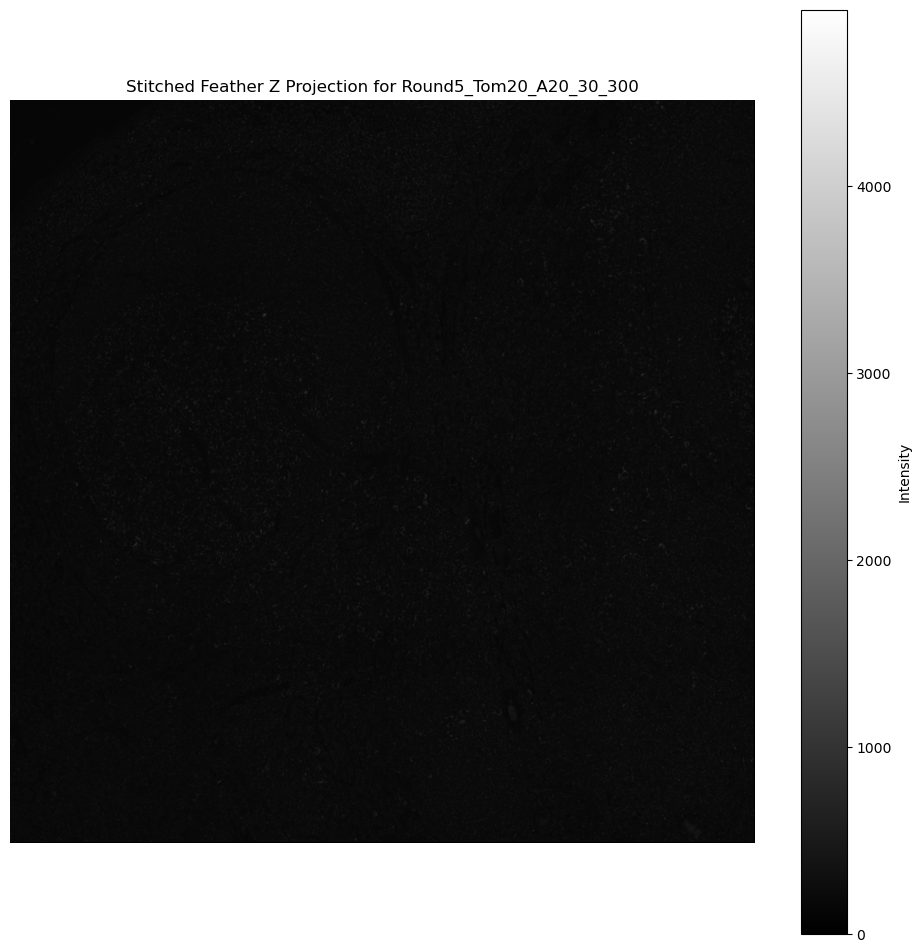

Stitching process completed for Round5_Tom20_A20_30_300.
--- Finished Round 11 of 15: Round5_Tom20_A20_30_300 ---


--- Processing Round 12 of 15: Round6_CD63_A10_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round6_CD63_A10_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round6_CD63_A10_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round6_CD63_A10_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective p

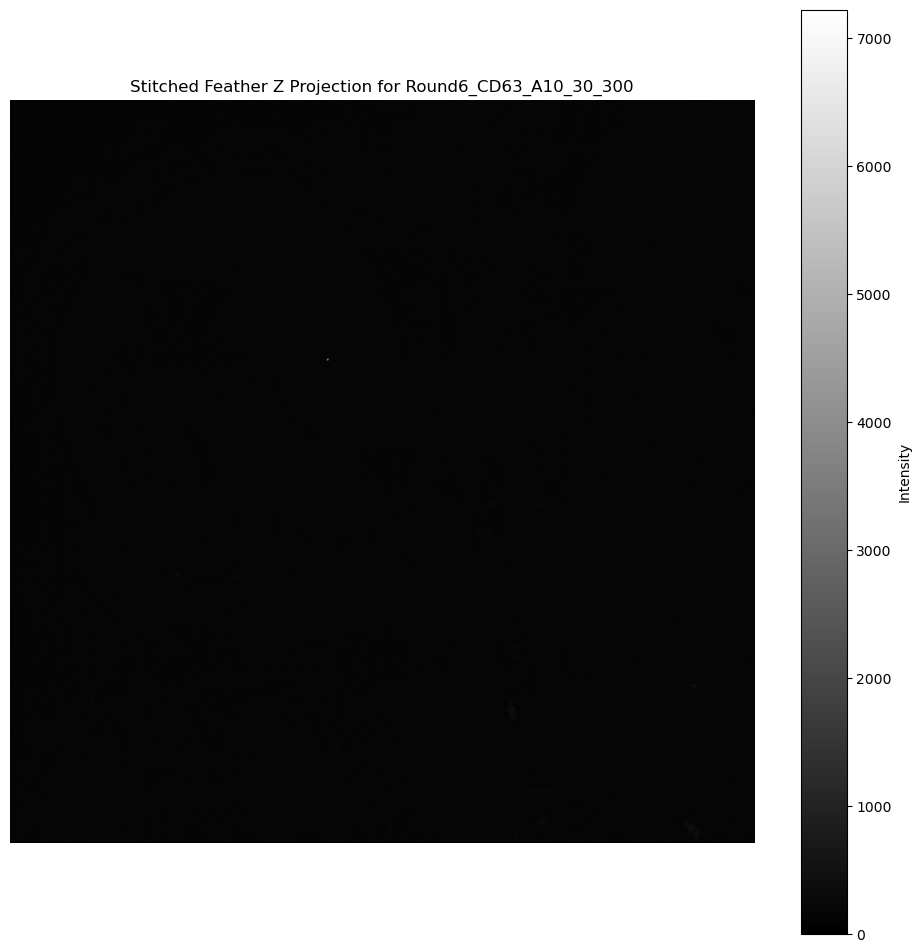

Stitching process completed for Round6_CD63_A10_30_300.
--- Finished Round 12 of 15: Round6_CD63_A10_30_300 ---


--- Processing Round 13 of 15: Round7_CD19_A36_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round7_CD19_A36_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round7_CD19_A36_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round7_CD19_A36_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective phy

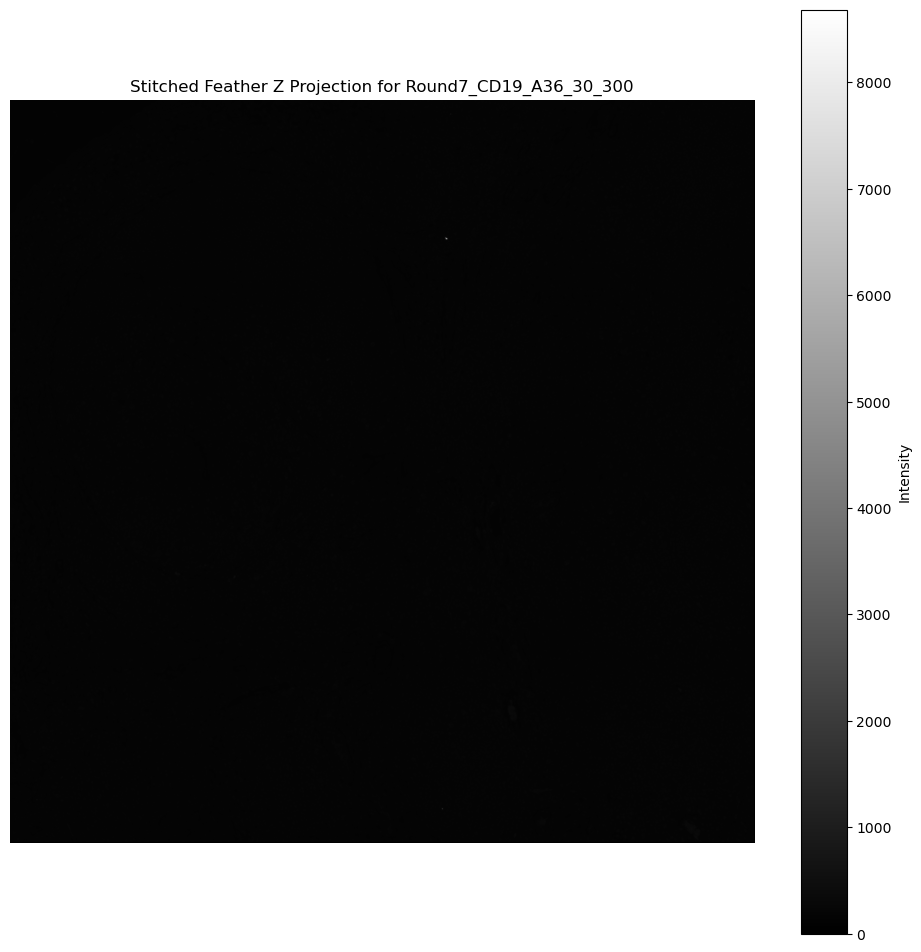

Stitching process completed for Round7_CD19_A36_30_300.
--- Finished Round 13 of 15: Round7_CD19_A36_30_300 ---


--- Processing Round 14 of 15: Round8_Vimentin_A5_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round8_Vimentin_A5_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round8_Vimentin_A5_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round8_Vimentin_A5_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
E

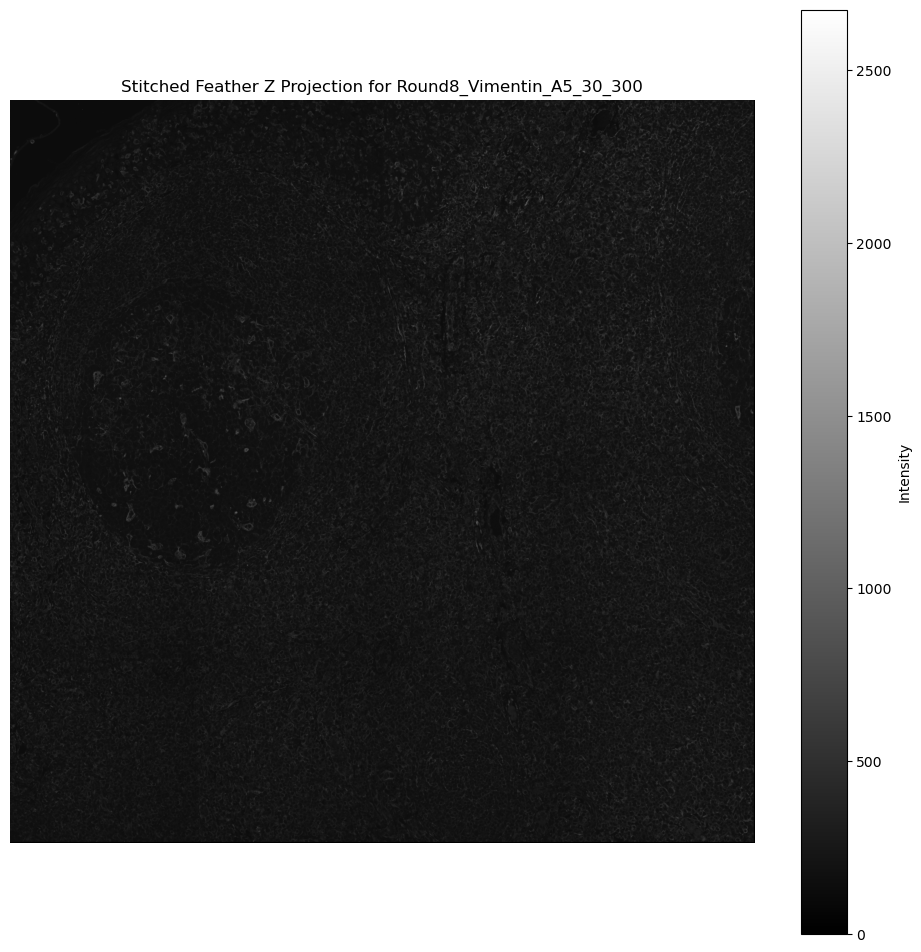

Stitching process completed for Round8_Vimentin_A5_30_300.
--- Finished Round 14 of 15: Round8_Vimentin_A5_30_300 ---


--- Processing Round 15 of 15: Round9_Ki67_A15_30_300 ---
Attempting to parse FusionStitcher_pair XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round9_Ki67_A15_30_300_FusionStitcher_pair.xml
FusionStitcher_pair XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round9_Ki67_A15_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Attempting to parse TeraStitcher XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round9_Ki67_A15_30_300.xml
Derived effective_pixel_width_um from TeraStitcher XML: 0.1500
Derived effective_pixel_height_um from TeraStitcher XML: 0.1500
Inferred overlap_pixels_x from TeraStitcher XML: 20 pixels
Inferred overlap_pixels_y from TeraStitcher XML: 20 pixels

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effecti

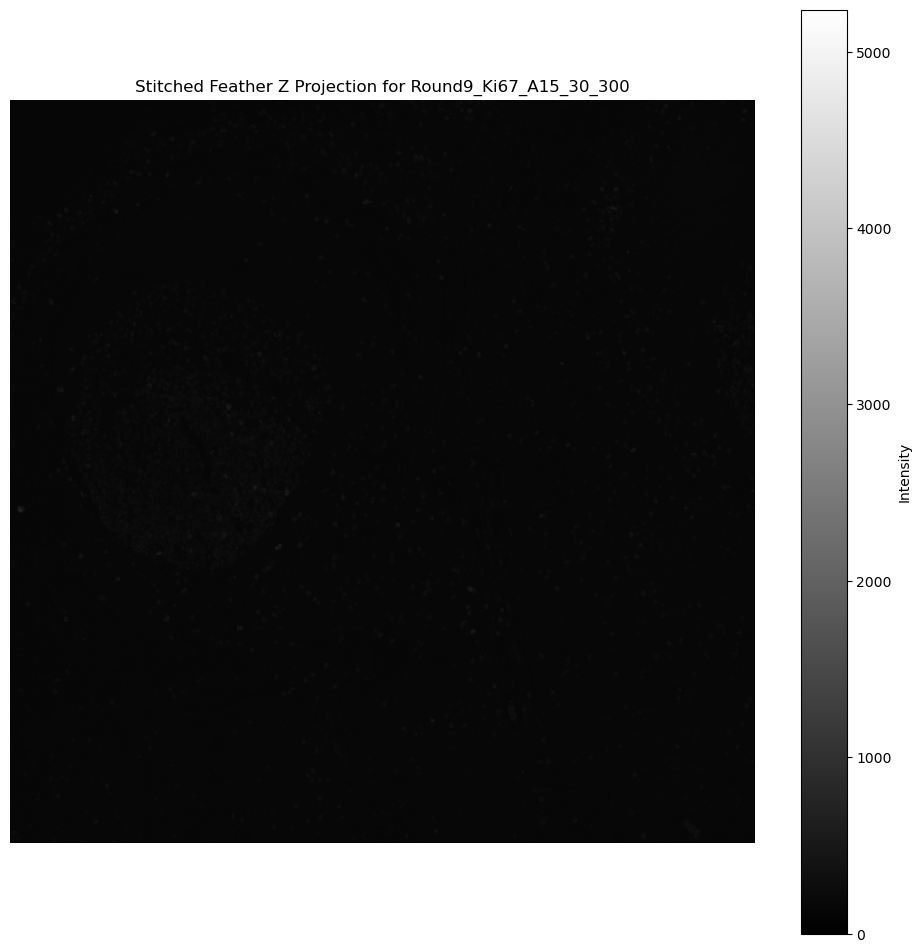

Stitching process completed for Round9_Ki67_A15_30_300.
--- Finished Round 15 of 15: Round9_Ki67_A15_30_300 ---



In [3]:
# Define the subfolder for analysis results based on the chosen method
analysis_results_subfolder = f"analysis_results_{OVERLAP_METHOD.replace('_', '').title()}_AtOverlap"
output_dir = os.path.join(data_path, analysis_results_subfolder)

# Create the analysis results subfolder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Ensured output directory exists: {output_dir}")

# Discover round names based on file pattern: any file ending with _FusionStitcher.ims
rounds_to_process = []
round_file_pattern = re.compile(r"(.*)_FusionStitcher\.ims") 

for item in os.listdir(data_path):
    match = round_file_pattern.match(item)
    if os.path.isfile(os.path.join(data_path, item)) and match:
        round_name = match.group(1)
        rounds_to_process.append(round_name)

if not rounds_to_process:
    print(f"No .ims files matching pattern '*_FusionStitcher.ims' found in {data_path}. Please check your data structure.")
else:
    rounds_to_process = sorted(list(set(rounds_to_process)))
    total_rounds = len(rounds_to_process)

    print(f"Found {total_rounds} unique rounds to process: {', '.join(rounds_to_process)}")

    for round_idx, current_round_name in enumerate(rounds_to_process):
        current_round_num = round_idx + 1
        print(f"\n--- Processing Round {current_round_num} of {total_rounds}: {current_round_name} ---")
        
        # Output filename now includes the analysis_results subfolder and method
        output_stitched_filename = os.path.join(output_dir, f"{current_round_name}_Stitched_{OVERLAP_METHOD.replace('_', '').title()}.tif")

        # 1. Parse metadata for the current round
        stitching_metadata = parse_stitching_metadata(current_round_name, data_path)

        if stitching_metadata:
            print("\n--- Metadata Summary ---")
            print(f"Number of tiles: {len(stitching_metadata['tile_info'])}")
            print(f"Tile pixel dimensions: {stitching_metadata['tile_pixel_width']}x{stitching_metadata['tile_pixel_height']}")
            print(f"Effective physical pixel size: {stitching_metadata['effective_pixel_width_um']:.4f}x{stitching_metadata['effective_pixel_height_um']:.4f} µm")
            print(f"Inferred overlap pixels (X, Y): {stitching_metadata['overlap_pixels_x']}, {stitching_metadata['overlap_pixels_y']}")
            print(f"Overlap Method: {OVERLAP_METHOD}")
            print("------------------------")

            # 2. Stitch the images for the current round
            stitched_result = stitch_max_z_projection(
                stitching_metadata,
                output_stitched_filename,
                current_round_name,
                current_round_num,
                total_rounds,
                overlap_method=OVERLAP_METHOD # Pass the chosen method
            )

            if stitched_result is not None:
                print(f"Stitching process completed for {current_round_name}.")
                if np.max(stitched_result) == 0:
                    print("WARNING: The final stitched image contains only zero values.")
            else:
                print(f"Stitching process failed for {current_round_name}.")
        else:
            print(f"Failed to parse stitching metadata for {current_round_name}, cannot proceed with stitching.")
        print(f"--- Finished Round {current_round_num} of {total_rounds}: {current_round_name} ---\n")
